In [2]:
import numpy as np
from datascience import *

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from matplotlib import patches
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

# 1. Loading Dataset and Initial Preprocessing

In [4]:
my_data_raw = Table.read_table('MyData1.csv').drop("SOC Level", "Standard Occupational Classification (SOC)", "Area Type", "Area Name", "Period")
my_data_raw.show(5)

Occupational Title,Base Quarter Employment Estimate,Projected Quarter Employment Estimate,Numeric Change,Percentage Change,Exits,Transfers,Total Job Openings,Median Hourly Wage,Median Annual Wage,Entry Level Education,Work Experience,Job Training
"Total, All Occupations",19920000,20412400,492400,2.5,1981550,2469420,4943370,24.73,51450,nan,nan,nan
Management Occupations,1669600,1705600,36000,2.2,102730,153320,292050,63.9,132918,nan,nan,nan
Top Executives,335600,342000,6400,1.9,17520,34380,58300,0,0,nan,nan,nan
Chief Executives,51800,51500,-300,-0.6,3190,3590,6480,104.13,0,Bachelor's degree,5 years or more,nan
General and Operations Managers,281500,288100,6600,2.3,14180,30600,51380,57.11,118793,Bachelor's degree,5 years or more,nan


In [7]:
#Dependent variable is whether there was a growth in the number of employment from the base to the projected. If "percentage change" is positive, there was growth (marked by True in var)
#function used to determine the dependent variable of each row
def positiveOrNegative(array):
    if array >= 0:
        return True
    if array < 1:
        return False
    
posOrNeg = my_data_raw.apply(positiveOrNegative, "Percentage Change")
my_data_raw = my_data_raw.with_column("Employment Projection Growth?", posOrNeg)

In [6]:
#Some occupations had missing median hourly wage or annual wage. This cell finds the missing wage using the other wage if available.
#For example: if an occupation has hourly wage, but no annual wage, we can multiply the hourly wage by 2080 to find the yearly wage because the average hours worked per year is 2080.
#If both annual and hourly wage are missing for an occupation, it is removed from the data
def hourlyToAnnual (hourly, annual):
    if (hourly > 0):
        return (hourly * 2080)
    if (hourly == 0):
        return annual
def annualToHourly (annual):
        return (annual/2080)
annualBasedOnHour = my_data_raw.apply(hourlyToAnnual, "Median Hourly Wage", "Median Annual Wage")
my_data_raw = my_data_raw.with_column("New Annual", annualBasedOnHour)
hourlyBasedOnAnnual = my_data_raw.apply(annualToHourly, "New Annual")
my_data_raw = my_data_raw.with_column("New Hourly", hourlyBasedOnAnnual)
my_data_raw.drop("Median Hourly Wage", "Median Annual Wage")
my_data_raw.relabel("New Annual", "Median Annual Wage").relabel("New Hourly", "Median Hourly Wage")
my_data_raw = my_data_raw.where("Median Hourly Wage", are.above(0))

In [10]:
#This cell is used to add additional useful columns to my data ("Employment % Decrease", "Employment % Increase", "Exit %", "Transfer%")
def propOfExits (employees, exits):
    proportion = (exits/employees) * 100
    return proportion
def propOfTransfers (employees, transfers):
    proportion = (transfers/employees) * 100
    return proportion
def propOfOpenings (employees, openings):
    proportion = (openings/employees) * 100
    return proportion
def propOfDecrease (exits, transfers):
    return (exits + transfers)

exitProportions = my_data_raw.apply(propOfExits, "Base Quarter Employment Estimate", "Exits")
my_data_raw = my_data_raw.with_column("Exit %", exitProportions)

transferProportions = my_data_raw.apply(propOfTransfers, "Base Quarter Employment Estimate", "Transfers")
my_data_raw = my_data_raw.with_column("Transfer %", transferProportions)

openingProportion = my_data_raw.apply(propOfOpenings, "Base Quarter Employment Estimate", "Total Job Openings")
my_data_raw = my_data_raw.with_column("Employment % Increase", openingProportion)

employmentDecrease = my_data_raw.apply(propOfDecrease, "Exit %", "Transfer %")
my_data_raw = my_data_raw.with_column("Employment % Decrease", employmentDecrease)
my_data_raw.show(5)

Occupational Title,Base Quarter Employment Estimate,Projected Quarter Employment Estimate,Numeric Change,Percentage Change,Exits,Transfers,Total Job Openings,Median Hourly Wage,Median Annual Wage,Entry Level Education,Work Experience,Job Training,Employment Projection Growth?,Exit %,Transfer %,Employment % Increase,Employment % Decrease
"Total, All Occupations",19920000,20412400,492400,2.5,1981550,2469420,4943370,24.73,51438.4,nan,nan,nan,True,9.94754,12.3967,24.8161,22.3442
Management Occupations,1669600,1705600,36000,2.2,102730,153320,292050,63.9,132912,nan,nan,nan,True,6.15297,9.18304,17.4922,15.336
Chief Executives,51800,51500,-300,-0.6,3190,3590,6480,104.13,216590,Bachelor's degree,5 years or more,nan,False,6.1583,6.9305,12.5097,13.0888
General and Operations Managers,281500,288100,6600,2.3,14180,30600,51380,57.11,118789,Bachelor's degree,5 years or more,nan,True,5.0373,10.8703,18.2522,15.9076
Legislators,2300,2300,0,0,140,190,330,29.5413,61446,Bachelor's degree,Less than 5 years,nan,True,6.08696,8.26087,14.3478,14.3478


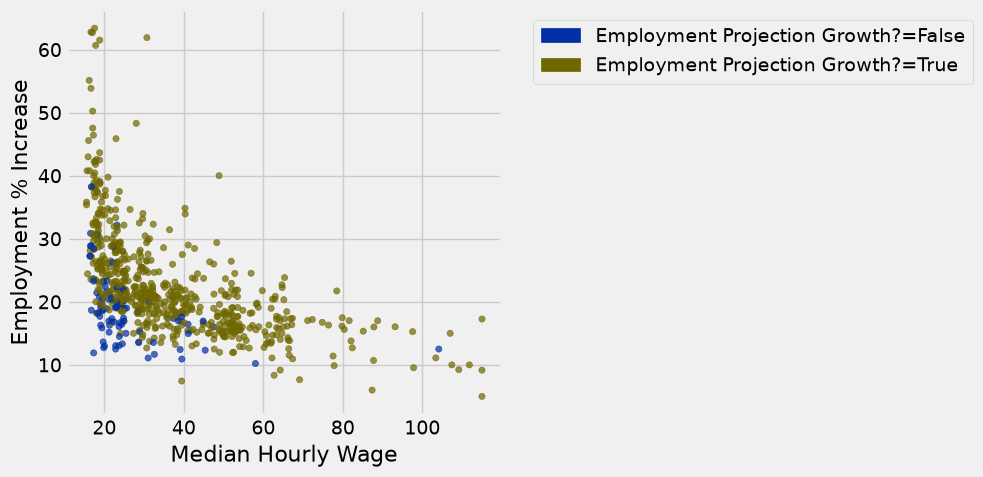

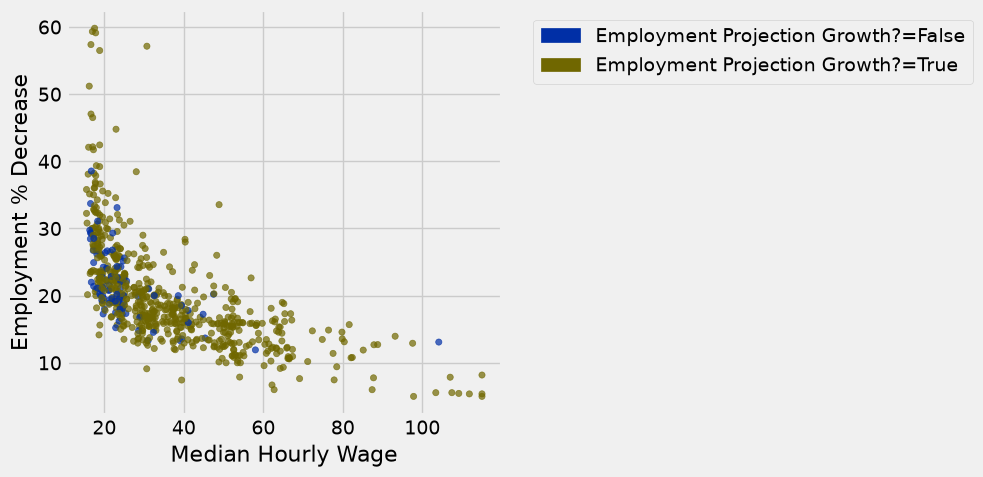

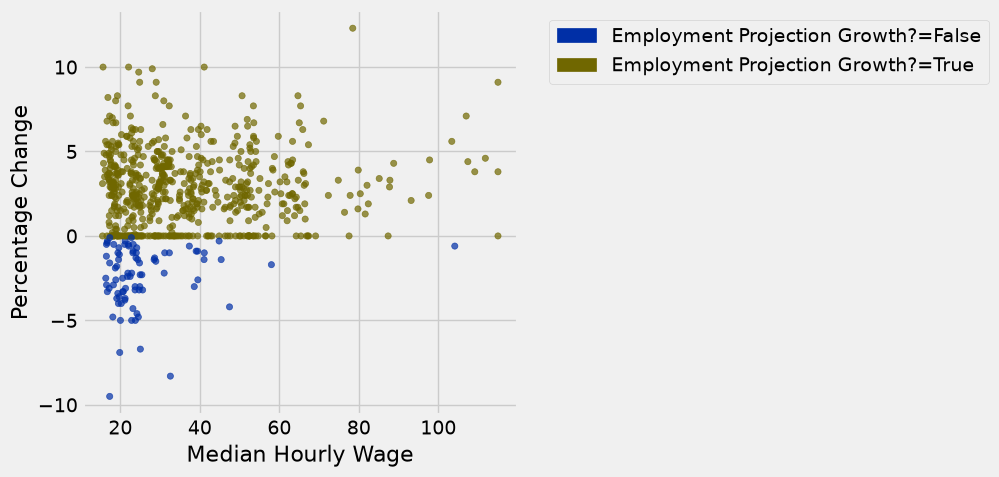

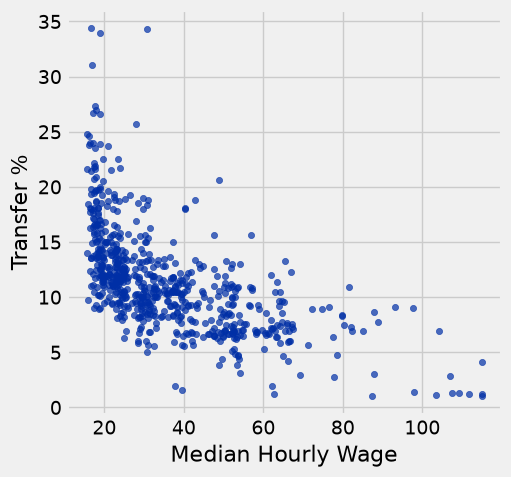

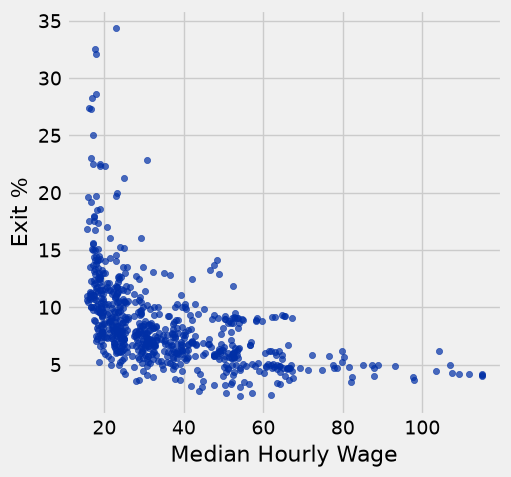

In [12]:
my_data_raw.scatter("Median Hourly Wage", "Employment % Increase", group = "Employment Projection Growth?")
my_data_raw.scatter("Median Hourly Wage", "Employment % Decrease", group = "Employment Projection Growth?")
my_data_raw.scatter("Median Hourly Wage", "Percentage Change", group = "Employment Projection Growth?")
my_data_raw.scatter("Median Hourly Wage", "Transfer %")
my_data_raw.scatter("Median Hourly Wage", "Exit %")

# 2. Regression Inference

In [13]:
my_data = my_data_raw.drop("Base Quarter Employment Estimate", "Projected Quarter Employment Estimate", "Numeric Change", "Percentage Change", "Exits", "Transfers", "Total Job Openings", "Median Annual Wage", "Entry Level Education", "Work Experience", "Job Training", "Exit %", "Transfer %", "Occupational Title", "Employment % Increase", "Employment Projection Growth?")

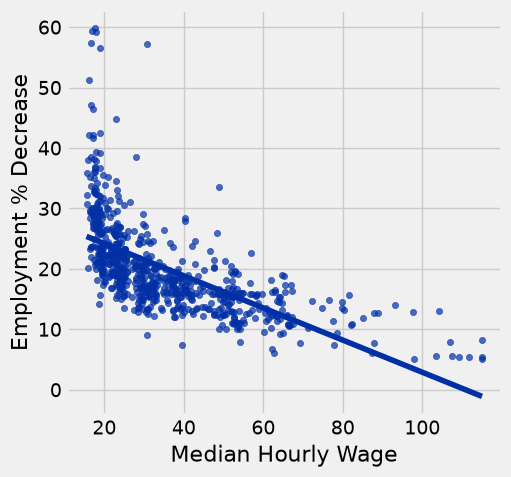

In [14]:
my_data.scatter(0, 1, fit_line=True)

In [15]:
def standard_units(arr):
    return (arr- np.mean(arr)) / np.std(arr)

def correlation(tbl, col1, col2):
    r = np.mean(standard_units(tbl.column(col1)) * standard_units(tbl.column(col2)))
    return r

cor = correlation(my_data, "Median Hourly Wage", "Employment % Decrease")
cor

-0.6296973231959696

In [16]:
def one_resample_r(tbl, col1, col2):
    resample = tbl.sample()
    resampleCorrelation = correlation(resample, col1, col2)
    return resampleCorrelation


one_resample = one_resample_r(my_data, "Median Hourly Wage", "Employment % Decrease")
one_resample

-0.62285403043977361

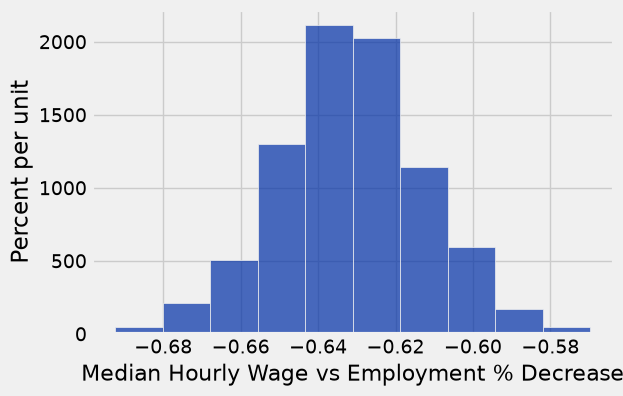

In [17]:
resampled_correlations = make_array()
for i in np.arange(1000):
    singleResampleR = one_resample_r(my_data, "Median Hourly Wage", "Employment % Decrease")
    resampled_correlations = np.append(resampled_correlations, singleResampleR)
    
resampled_correlations
Table().with_column("Median Hourly Wage vs Employment % Decrease", resampled_correlations).hist()

In [18]:
lower_bound = percentile(2.5, resampled_correlations)
upper_bound = percentile(97.5, resampled_correlations)
reject = True

print(f"95% CI: [{lower_bound}, {upper_bound}] , Reject the null: {reject}")

95% CI: [-0.6702499723520422, -0.5936772165780407] , Reject the null: True


## Analyzing Residuals

In [19]:
# DON'T EDIT THE PARAMETERS FUNCTION
def parameters(tbl, colx, coly):
    x = tbl.column(colx)
    y = tbl.column(coly)
    
    r = correlation(tbl, colx, coly)
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_sd = np.std(x)
    y_sd = np.std(y)
    
    slope = (y_sd / x_sd) * r
    intercept = y_mean - (slope * x_mean)
    return make_array(slope, intercept)

my_slope = (parameters(my_data, "Median Hourly Wage", "Employment % Decrease")).item(0)
my_intercept = (parameters(my_data, "Median Hourly Wage", "Employment % Decrease")).item(1)
print (my_slope, my_intercept)

-0.2660395220085212 29.487195577763192


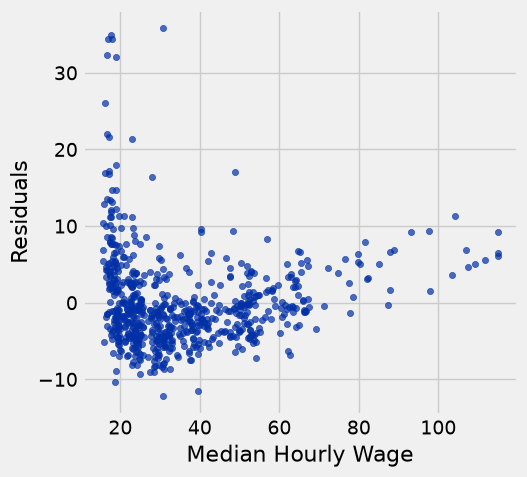

In [21]:
predicted_var2 = (my_slope * my_data.column("Median Hourly Wage")) + my_intercept
residuals_var2 = (my_data.column("Employment % Decrease")) - predicted_var2


originalTable_with_residuals = my_data.with_column("Residuals", residuals_var2)

originalTable_with_residuals.scatter("Median Hourly Wage", "Residuals")

In [22]:
correlation(originalTable_with_residuals, "Residuals", "Median Hourly Wage")

-1.4416809131364351e-16

## Prediction Intervals

In [23]:
def one_resample_prediction(tbl, colx, coly, xvalue):
    resample = tbl.sample()
    resampleSlope = parameters(resample, colx, coly).item(0)
    resampleIntercept = parameters(resample, colx, coly).item(1)
    predictedY = (resampleSlope * xvalue) + resampleIntercept
    return predictedY
chosen_var1 = 40

maria_prediction = one_resample_prediction(my_data, "Median Hourly Wage", "Employment % Decrease", chosen_var1)
maria_prediction

18.909849467525845

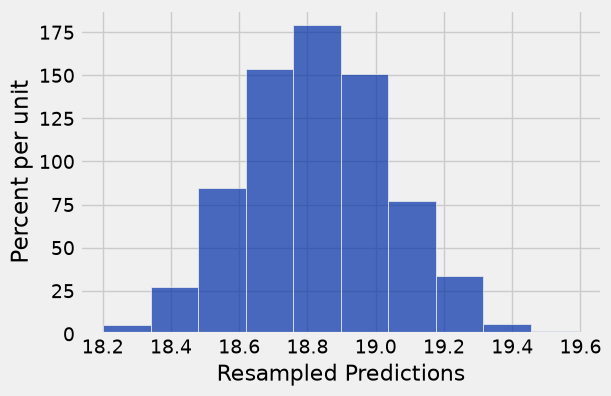

In [24]:
resampled_predictions = make_array()

for j in np.arange(1000):
    onePrediction = one_resample_prediction(my_data, "Median Hourly Wage", "Employment % Decrease", chosen_var1)
    resampled_predictions = np.append(resampled_predictions, onePrediction)

# Don't change/delete the code below in this cell, just run to visualize the distribution
Table().with_column("Resampled Predictions", resampled_predictions).hist()

In [25]:
lower_bound_maria = percentile(0.5, resampled_predictions)
upper_bound_maria = percentile(99.5, resampled_predictions)

# Don't delete/modify the code below in this cell
print(f"99% CI: [{lower_bound_maria}, {upper_bound_maria}]")

99% CI: [18.297503390534807, 19.354992228772662]


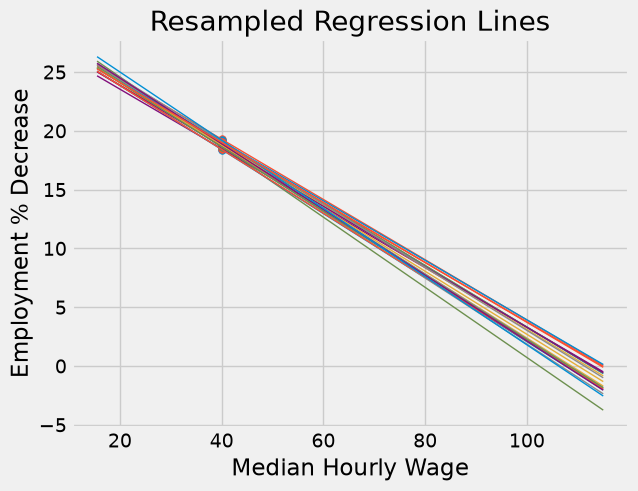

In [26]:
lines = Table(['slope','intercept'])

x=chosen_var1

for i in np.arange(20):
    resamp = originalTable_with_residuals.sample(with_replacement=True)
    resample_pars = parameters(resamp, "Median Hourly Wage", "Employment % Decrease") 
    slope = resample_pars.item(0)
    intercept = resample_pars.item(1)
    lines.append([slope, intercept])
    
lines['prediction at x='+str(x)] = lines.column('slope')*x + lines.column('intercept')
xlims = [min(originalTable_with_residuals.column("Median Hourly Wage")), max(originalTable_with_residuals.column("Median Hourly Wage"))]
left = xlims[0]*lines[0] + lines[1]
right = xlims[1]*lines[0] + lines[1]
fit_x = x*lines['slope'] + lines['intercept']
for i in range(20):
    plt.plot(xlims, np.array([left[i], right[i]]), lw=1)
    plt.scatter(x, fit_x[i], s=30)
plt.ylabel("Employment % Decrease"); 
plt.xlabel("Median Hourly Wage");
plt.title("Resampled Regression Lines");

# 3. Classification

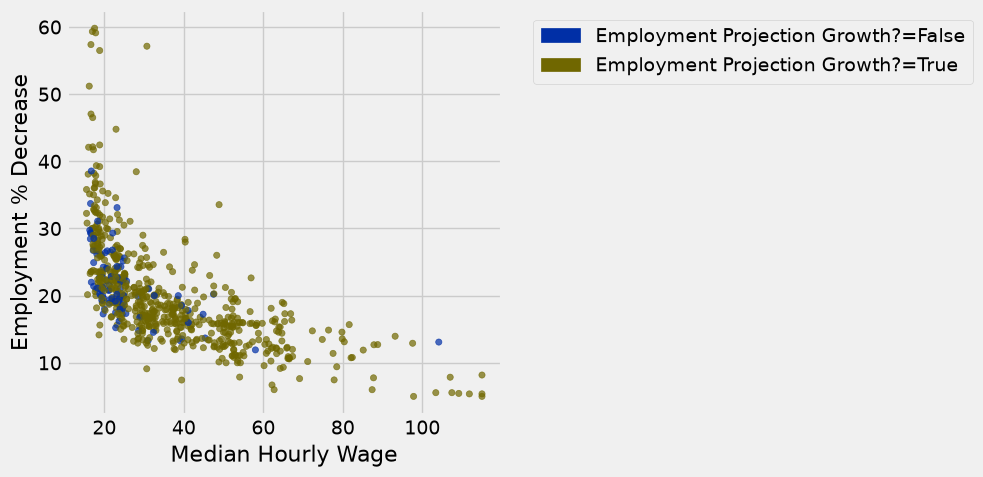

In [29]:
my_data_raw.scatter("Median Hourly Wage", "Employment % Decrease", group = "Employment Projection Growth?")

In [30]:
def distance(arr1, arr2):
    euc_dist = np.sqrt(sum ((arr1 - arr2) ** 2))
    return euc_dist
distance_example = distance(make_array(1, 2, 3), make_array(4, 5, 6))
distance_example

5.196152422706632

In [33]:
my_data_raw = my_data_raw.where("Entry Level Education", are.not_equal_to("nan"))

In [36]:
#I ranked the attributes of “Entry Level Education” according to prestige (7 - highest prestiege and 0 - lowest prestiege)

levelArray = make_array()
def levelEd (education):
    if (education == "No formal educational credential"):
        return 0
    if (education == "High school diploma or equivalent"):
        return 1
    if (education == "Some college, no degree"):
        return 2
    if (education == "Postsecondary non-degree award"):
        return 3
    if (education == "Associate's degree"):
        return 4
    if (education == "Bachelor's degree"):
        return 5
    if (education == "Master's degree"):
        return 6
    if (education == "Doctoral or professional degree"):
        return 7
levelArray = my_data_raw.apply(levelEd, "Entry Level Education")
my_data_raw = my_data_raw.with_column("Education Leveled", levelArray)
my_data_raw.show(10)

Occupational Title,Base Quarter Employment Estimate,Projected Quarter Employment Estimate,Numeric Change,Percentage Change,Exits,Transfers,Total Job Openings,Median Hourly Wage,Median Annual Wage,Entry Level Education,Work Experience,Job Training,Employment Projection Growth?,Exit %,Transfer %,Employment % Increase,Employment % Decrease,Education Leveled
Chief Executives,51800,51500,-300,-0.6,3190,3590,6480,104.13,216590,Bachelor's degree,5 years or more,nan,False,6.1583,6.9305,12.5097,13.0888,5
General and Operations Managers,281500,288100,6600,2.3,14180,30600,51380,57.11,118789,Bachelor's degree,5 years or more,nan,True,5.0373,10.8703,18.2522,15.9076,5
Legislators,2300,2300,0,0,140,190,330,29.5413,61446,Bachelor's degree,Less than 5 years,nan,True,6.08696,8.26087,14.3478,14.3478,5
Advertising and Promotions Managers,5200,5200,0,0,210,690,900,65.4,136032,Bachelor's degree,Less than 5 years,nan,True,4.03846,13.2692,17.3077,17.3077,5
Marketing Managers,60300,61100,800,1.3,2880,6580,10260,81.59,169707,Bachelor's degree,5 years or more,nan,True,4.77612,10.9121,17.0149,15.6882,5
Sales Managers,108600,109900,1300,1.2,5320,10500,17120,63.81,132725,Bachelor's degree,Less than 5 years,nan,True,4.89871,9.66851,15.7643,14.5672,5
Public Relations Managers,9200,9500,300,3.3,420,820,1540,74.82,155626,Bachelor's degree,5 years or more,nan,True,4.56522,8.91304,16.7391,13.4783,5
Fundraising Managers,3800,3900,100,2.6,170,340,610,58.84,122387,Bachelor's degree,5 years or more,nan,True,4.47368,8.94737,16.0526,13.4211,5
Administrative Services Managers,37400,38400,1000,2.7,2660,3130,6790,51.81,107765,Bachelor's degree,Less than 5 years,nan,True,7.1123,8.36898,18.1551,15.4813,5
Facilities Managers,20700,21300,600,2.9,1350,1800,3750,50.09,104187,Bachelor's degree,Less than 5 years,nan,True,6.52174,8.69565,18.1159,15.2174,5


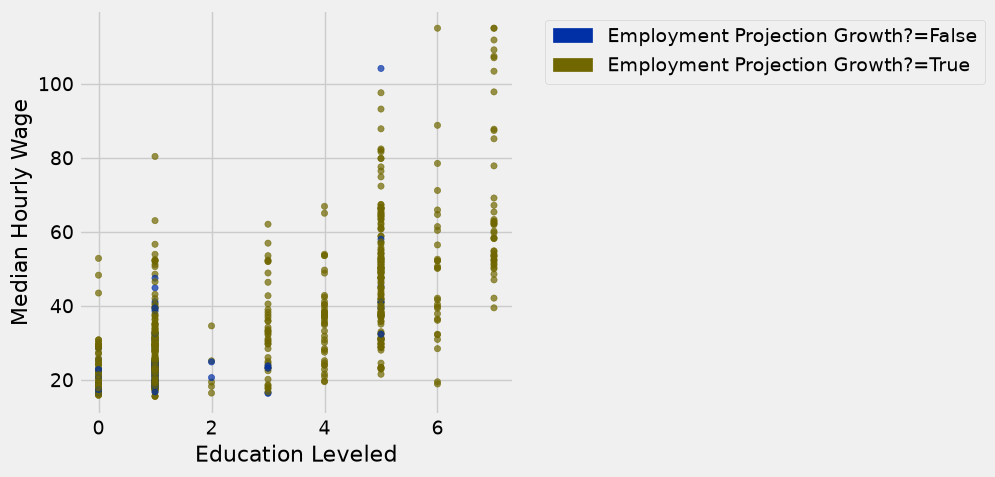

In [37]:
my_data_raw.scatter("Education Leveled", "Median Hourly Wage", group = "Employment Projection Growth?")

In [38]:
(my_data_raw.where("Median Hourly Wage", are.above(60)).where("Employment Projection Growth?", are.equal_to(False))).num_rows

1

In [39]:
my_data_raw.where("Median Hourly Wage", are.above(60)).num_rows

70

In [40]:
70/667

0.10494752623688156

In [41]:
correlation(my_data_raw, "Education Leveled", "Median Hourly Wage")

0.69950735988783552

In [42]:
trainNum = 667 * 0.75
testNum = 667 * 0.25
print (trainNum, testNum)
#round 500.25 training set down to 500 and round 166.75 testing set up to 167

500.25 166.75


## K Fold Cross Validation

In [44]:
#k fold cross validation

shuffled_table = my_data_raw.sample(with_replacement = False)
test1 = (np.arange(133))
train1 = (np.arange(133, 667))

test2 = (np.arange(133, 266))
firstRange2 = np.arange(133)
secondRange2 = np.arange(266, 667)
train2 = (np.concatenate((firstRange2, secondRange2)))

test3 = (np.arange(266, 399))
firstRange3 = np.arange(266)
secondRange3 = np.arange(399, 667)
train3 = (np.concatenate((firstRange3, secondRange3)))

test4 = (np.arange(399, 532))
firstRange4 = np.arange(399)
secondRange4 = np.arange(532, 667)
train4 = (np.concatenate((firstRange4, secondRange4)))

test5 = (np.arange(532, 667))
train5 = (np.arange(532))

## K-Nearest-Neighbors

In [48]:
chosen_features = make_array("Base Quarter Employment Estimate", "Projected Quarter Employment Estimate", "Numeric Change", "Exits", "Transfers", "Total Job Openings", "Median Hourly Wage", "Median Annual Wage", "Exit %", "Transfer %", "Employment % Increase", "Employment % Decrease", "Education Leveled")
chosen_features

array(['Base Quarter Employment Estimate',
       'Projected Quarter Employment Estimate', 'Numeric Change', 'Exits',
       'Transfers', 'Total Job Openings', 'Median Hourly Wage',
       'Median Annual Wage', 'Exit %', 'Transfer %',
       'Employment % Increase', 'Employment % Decrease',
       'Education Leveled'],
      dtype='<U37')

In [49]:
def row_to_array(row, features):
    """Converts a row to an array of its features."""
    arr = make_array()
    for feature in features:
        arr = np.append(arr, row.item(feature))
    return arr
def classify(test_row, k, train, features):
    test_row_features_array = row_to_array(test_row, features)
    distances = make_array()
    for train_row in train.rows:
        train_row_features_array = row_to_array(train_row, features)
        row_distance = distance(train_row_features_array, test_row_features_array)
        distances = np.append(distances, row_distance)
    train_with_distances = train.with_column("Distance", distances)
    nearest_neighbors = train_with_distances.sort("Distance").take(np.arange(k))
    most_common_label = nearest_neighbors.group("Employment Projection Growth?").sort("count", descending = True).column("Employment Projection Growth?").item(0)
    return most_common_label

In [51]:
def three_classify(row):
    prediction = classify(row, 3, train, chosen_features)
    return prediction

def getLabels(testData):
    predictionsArray = make_array()
    for eachRow in (np.arange(testData.num_rows)):
        testRow = testData.row(eachRow)
        eachPrediction = three_classify(testRow)
        predictionsArray = np.append(predictionsArray, eachPrediction)
    return predictionsArray == 1

#labels = getLabels(test)

#test_with_prediction = test.with_column("Prediction", labels)

def checkIfCorrect (testingData, actual, predicted):
    numCorrect = 0
    for rowEach in (np.arange(testingData.num_rows)):
        if (testingData.column(actual).item(rowEach) == testingData.column(predicted).item(rowEach)):
            numCorrect = numCorrect + 1
    return numCorrect

In [53]:
def correctnessColumn (dataTesting, actualC, predictedC):
    correctness = make_array()
    for oneRow in (np.arange(dataTesting.num_rows)):
        if ((dataTesting.column(actualC)).item(oneRow) == (dataTesting.column(predictedC)).item(oneRow)):
            result = True
        if ((dataTesting.column(actualC)).item(oneRow) != (dataTesting.column(predictedC)).item(oneRow)):
            result = False
        correctness = np.append(correctness, result)
    return correctness

In [54]:
withoutWage = make_array()
trainArray = make_array(train1, train2, train3, train4, train5)
testArray = make_array(test1, test2, test3, test4, test5)
for x in np.arange(5):
    train = shuffled_table.take(trainArray[x])
    test = shuffled_table.take(testArray[x])

    different_features = make_array("Exit %", "Transfer %")

    def another_classifier(newRow):
        newPrediction = classify(newRow, 5, train, different_features)
        return newPrediction

    def newGetLabels(testDataNew):
        predictionsArrayNew = make_array()
        for eachRowNew in (np.arange(testDataNew.num_rows)):
            testRowNew = testDataNew.row(eachRowNew)
            eachPredictionNew = another_classifier(testRowNew)
            predictionsArrayNew = np.append(predictionsArrayNew, eachPredictionNew)
        return predictionsArrayNew == 1

    new_labels = newGetLabels(test)
    new_test_with_prediction = test.with_column("New Prediction", new_labels)
    new_labels_correct = checkIfCorrect(new_test_with_prediction,"Employment Projection Growth?", "New Prediction")
    new_accuracy = new_labels_correct/new_test_with_prediction.num_rows
    withoutWage = np.append(withoutWage, new_accuracy)
withoutWage

array([ 0.87218045,  0.87218045,  0.84210526,  0.86466165,  0.88148148])

In [55]:
withWage = make_array()
trainArray = make_array(train1, train2, train3, train4, train5)
testArray = make_array(test1, test2, test3, test4, test5)
for x in np.arange(5):
    train = shuffled_table.take(trainArray[x])
    test = shuffled_table.take(testArray[x])

    different_features = make_array("Exit %", "Transfer %", "Median Hourly Wage", "Median Annual Wage")

    def another_classifier(newRow):
        newPrediction = classify(newRow, 5, train, different_features)
        return newPrediction

    def newGetLabels(testDataNew):
        predictionsArrayNew = make_array()
        for eachRowNew in (np.arange(testDataNew.num_rows)):
            testRowNew = testDataNew.row(eachRowNew)
            eachPredictionNew = another_classifier(testRowNew)
            predictionsArrayNew = np.append(predictionsArrayNew, eachPredictionNew)
        return predictionsArrayNew == 1

    new_labels = newGetLabels(test)
    new_test_with_prediction = test.with_column("New Prediction", new_labels)
    new_labels_correct = checkIfCorrect(new_test_with_prediction,"Employment Projection Growth?", "New Prediction")
    new_accuracy = new_labels_correct/new_test_with_prediction.num_rows
    withWage = np.append(withWage, new_accuracy)
withWage

array([ 0.88721805,  0.84210526,  0.85714286,  0.84962406,  0.8962963 ])

In [56]:
np.average(withWage)

0.86647730437204129

In [57]:
np.average(withoutWage)

0.86652186020607069

In [58]:
withWage - withoutWage

array([ 0.01503759, -0.03007519,  0.01503759, -0.01503759,  0.01481481])

In [59]:
#mean difference
avgDiff = np.average(withWage - withoutWage)
avgDiff

-4.4555834029536002e-05

In [60]:
std = np.std(withWage - withoutWage)

In [61]:
#standard Error
ste = np.std(withWage - withoutWage)/(np.sqrt(5))
ste

0.008490873787500474

In [62]:
t_value = avgDiff/ste
t_value

-0.0052474969178233728

In [63]:
#Degrees of Freedom (df)
df = 5-1

In [64]:
#Null Hyp: Mean difference is close/at 0 -> adding wage does not have a significant effect on the model
#Alt Hyp: Mean difference is far from 0 -> adding wage does have a significant effect on the model

#P-value 0.013 < 0.05. This means that we can reject the null hyp. Addition of wages (hourly + annual) as features does have a significant effect on the performance of the KNN model